# EDA

In [2]:
# Imports

import os
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder , StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_sample_weight

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath(".."))

from preprocessing import get_X_y

In [3]:
# Data Load

df_train = pd.read_csv(r"../dataset/UNSW_NB15_training-set.csv")

df_test = pd.read_csv(r"../dataset/UNSW_NB15_testing-set.csv")
df_train

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175336,175337,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,13,24,0,0,0,24,24,0,Generic,1
175337,175338,0.505762,tcp,-,FIN,10,8,620,354,33.612649,...,1,2,0,0,0,1,1,0,Shellcode,1
175338,175339,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,3,13,0,0,0,3,12,0,Generic,1
175339,175340,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,14,30,0,0,0,30,30,0,Generic,1


In [4]:
# Stats

df_train.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,1.753410e+05,175341.000000,175341.000000,1.753410e+05,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,87671.000000,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,9.540619e+04,179.546997,79.609567,7.345403e+07,...,5.383538,4.206255,8.729881,0.014948,0.014948,0.133066,6.955789,9.100758,0.015752,0.680622
std,50616.731112,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05,1.654010e+05,102.940011,110.506863,1.883574e+08,...,8.047104,5.783585,10.956186,0.126048,0.126048,0.701208,8.321493,10.756952,0.124516,0.466237
min,1.000000,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,43836.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.278614e+01,62.000000,0.000000,1.305334e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,87671.000000,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3.225807e+03,254.000000,29.000000,8.796748e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,131506.000000,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,1.250000e+05,254.000000,252.000000,8.888889e+07,...,5.000000,3.000000,12.000000,0.000000,0.000000,0.000000,9.000000,12.000000,0.000000,1.000000
max,175341.000000,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,51.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


In [5]:
# Null Values

print(df_train.isnull().sum())

id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_cat 

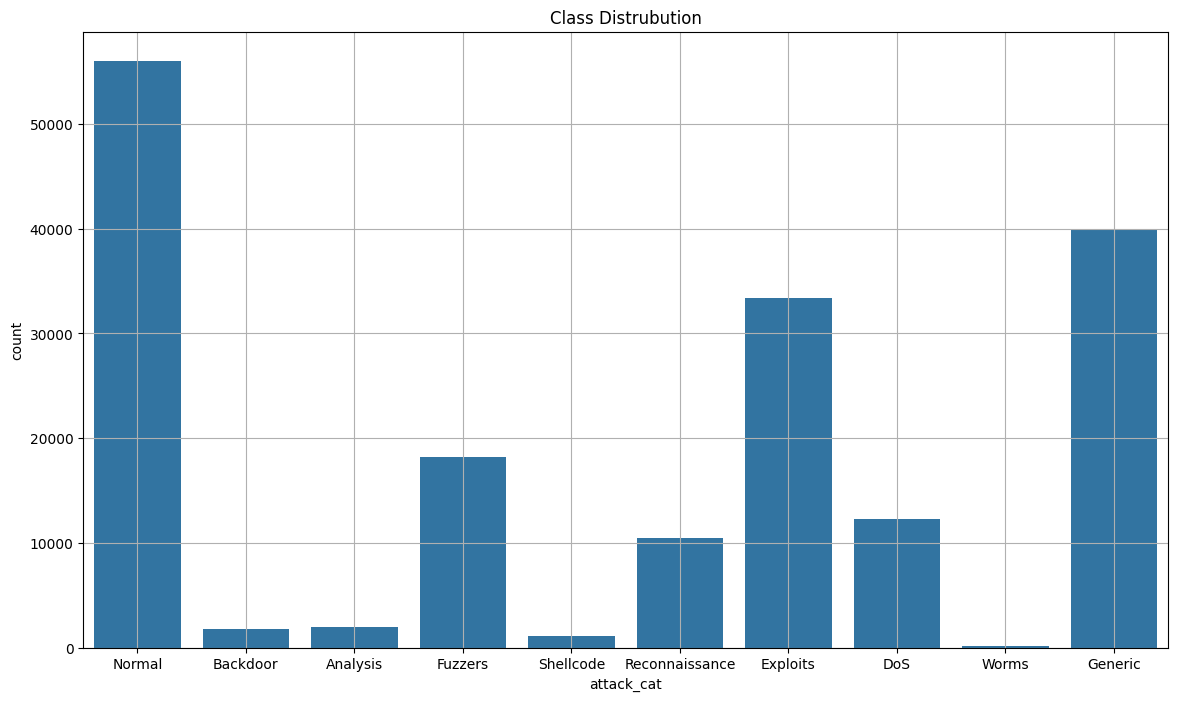

In [6]:
# Class Distribution

plt.figure(figsize = (14 , 8))

sns.countplot(
    x = "attack_cat" ,
    data = df_train
)

plt.title("Class Distrubution")
plt.grid()
plt.show()

# Classes are highly imbalanced in this dataset

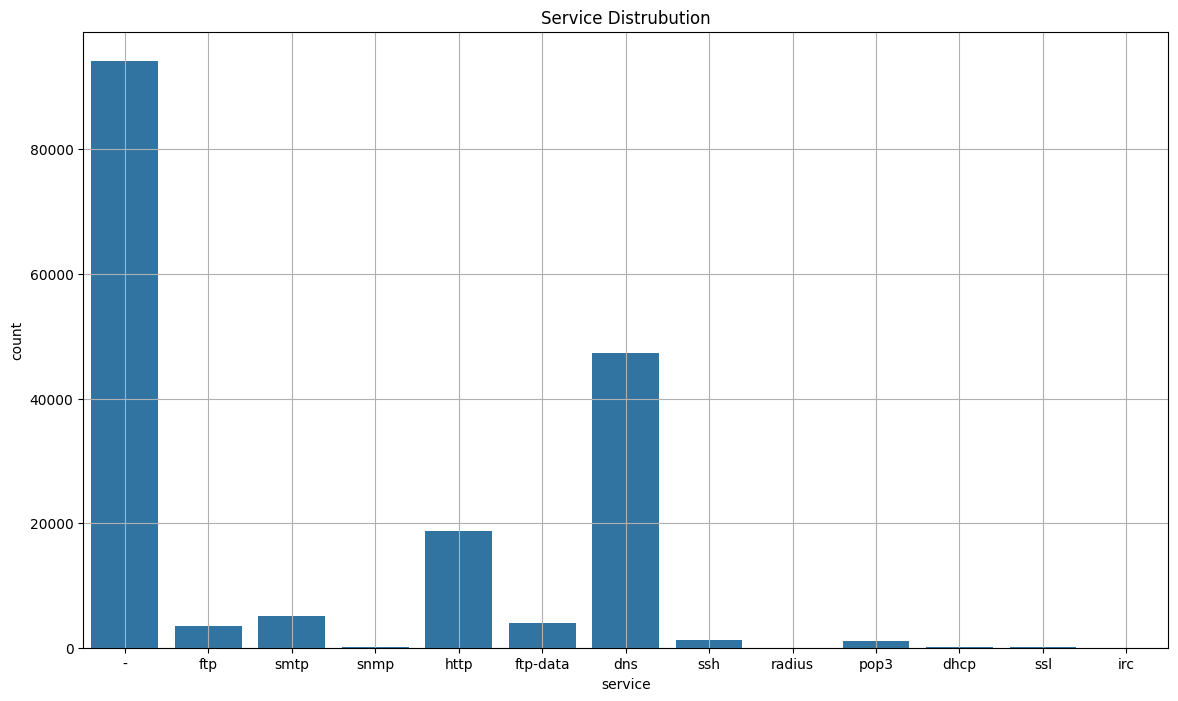

In [8]:
# Service Distribution

plt.figure(figsize = (14 , 8))

sns.countplot(
    x = "service" ,
    data = df_train
)

plt.title("Service Distrubution")
plt.grid()
plt.show()

# In this dataset "-" means an unrecognized service but also it is not a null value cause this service is not identified 

In [9]:
# Number of Cat & num column

cat_cols = df_train.select_dtypes(include = ["object" , "string"]).columns

num_cols = df_train.select_dtypes(include = ["number"]).columns

print("Numerical Columns : ")
print(num_cols)
print(f"Count : {len(num_cols)}")

print()

print("Catagorial Columns : ")
print(cat_cols)
print(f"Count : {len(cat_cols)}")

Numerical Columns : 
Index(['id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl',
       'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit',
       'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat',
       'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src',
       'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
       'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'label'],
      dtype='str')
Count : 41

Catagorial Columns : 
Index(['proto', 'service', 'state', 'attack_cat'], dtype='str')
Count : 4


# Needed Encoding for 4 Columns

In [11]:
# Feature Improtance

X_train , y_train = get_X_y(df_train)

X_test , y_test = get_X_y(df_test)

weights = compute_sample_weight(
    y = y_train ,
    class_weight = "balanced"
)

cat_cols = X_train.select_dtypes(include = ["object" , "string"]).columns
num_cols = X_train.select_dtypes(include = ["number"]).columns

preprocess = ColumnTransformer([
    ("cat" , OrdinalEncoder(handle_unknown = "use_encoded_value" , unknown_value = -1) , cat_cols) ,
    ("num" , "passthrough" , num_cols)
])

model = Pipeline([
    ("preprocess" , preprocess) ,
    ("RF" , RandomForestClassifier(
        n_jobs=-1 , 
        random_state = 42 
    ))
]) 

model.fit(X_train , y_train , RF__sample_weight = weights)

y_pred = model.predict(X_test)

rf = model.named_steps["RF"]
val = rf.feature_importances_

imp = pd.Series(
    val ,
    index = X_train.columns
).sort_values(ascending = False)


print("Feature Importance :")
print(imp)

print()
print(f"F1 Score : {f1_score(y_test , y_pred , average="weighted")}")

Feature Importance :
sbytes               0.109600
smean                0.094833
ct_dst_src_ltm       0.057768
sttl                 0.050767
ct_srv_dst           0.045760
sload                0.036153
ct_dst_sport_ltm     0.034737
ct_srv_src           0.034695
proto                0.033914
dbytes               0.031762
dmean                0.028956
dload                0.028678
dur                  0.027347
ct_state_ttl         0.025685
ct_src_dport_ltm     0.025484
state                0.022374
rate                 0.021865
sinpkt               0.020869
trans_depth          0.019755
ct_src_ltm           0.019660
sjit                 0.018891
ct_dst_ltm           0.018824
ct_flw_http_mthd     0.016001
synack               0.015484
dpkts                0.015117
tcprtt               0.015000
ackdat               0.014867
dloss                0.014791
dinpkt               0.014717
spkts                0.013266
djit                 0.012491
sloss                0.011343
response_body_len  